# Projectile Motion — A Computational Physics Demo

## Why does this matter?

Every time a soccer player kicks a ball, an archer releases an arrow, or a rocket leaves a launchpad, the same physics is at work: an object launched into the air follows a curved path called a **trajectory**. In a first physics class, we usually assume air resistance doesn't exist — it makes the math clean. But in reality, air pushes back against anything moving through it, and that changes everything.

In this notebook, we'll use Python to simulate a projectile's flight **with and without air resistance** and compare the two. We'll see exactly how much air resistance matters, what angle launches a projectile the farthest, and why that answer changes when air is involved.

---

## What is this notebook?

This is a **Jupyter notebook** — a document that mixes explanatory text (like this) with live, runnable code. You can run each code cell by clicking it and pressing **Shift + Enter**. The output appears directly below.

You don't need to understand every line of code right away. Focus on the *physics* first — the code is just the calculator doing the heavy lifting.

---

## Learning goals

By the end of this demo, you should be able to:
- Describe the forces acting on a projectile in flight
- Explain what air drag is and how it changes a trajectory
- Understand why 45° maximizes range without drag — and why that shifts with drag
- Explain at a high level how a computer can simulate physics one small time step at a time


## Step 1 — Load the tools

Before we do any physics, we load three Python libraries. Think of these as toolboxes:
- **`math`** — standard math functions like sine, cosine, and square root
- **`numpy`** — a scientific calculator that works on entire lists of numbers at once (very fast)
- **`matplotlib`** — a plotting library that draws graphs

In [234]:
import math as m                      # trig functions: cos, sin, sqrt, radians
import numpy as np                     # fast array math and utilities like argmax
import matplotlib.pyplot as plt        # plotting


## Step 2 — Define the physical setup

**What information do we need to describe the flight of a ball?**

Think about it before reading on. At minimum, we need:
1. How fast is it launched, and at what angle?
2. How heavy is it, and how big?
3. What is the air like?
4. Where does it start?

All of these are defined below as variables. Keeping them in one place makes it easy to change the scenario — try different values and re-run to see how the physics changes!

### The drag model

We model our projectile as a **sphere** (like a cannonball or soccer ball). Air drag depends on:
- The **shape** of the object — captured by the drag coefficient $C_d$ (0.47 for a sphere)
- The **size** of the object — specifically the cross-sectional area $A = \pi R^2$, the circle the object "presents" to the air as it flies
- The **density of air** $\rho$
- The **speed** of the object squared — faster means much more drag

> **Note:** Cross-sectional area is $\pi R^2$, the area of the circle you'd see if you looked at the sphere head-on. This is *not* the surface area of the sphere ($4\pi R^2$), which describes the whole outer skin.

In [235]:
# --- Launch conditions ---
v_0 = 25            # initial speed (m/s) — roughly 90 km/h, like a hard baseball throw
theta_launch = 45   # launch angle for Part A trajectory (degrees)

# --- Projectile physical properties ---
mass = 10           # mass (kg)
C_d = 0.47          # drag coefficient — 0.47 is standard for a sphere
R_sphere = 0.1      # radius of sphere (m) — about the size of a softball
rho_air = 1.225     # air density at sea level (kg/m^3)

# --- Initial position and time ---
x_0 = 0             # starting x position (m)
y_0 = 0             # starting y position (m)
start_time = 0      # starting time (s)
time_step = 0.01    # simulation time step (s) — each 'tick' of our virtual clock

# --- Constant accelerations ---
a_x = 0             # no horizontal acceleration (ignoring wind)
a_y = -9.81         # gravitational acceleration (m/s^2, downward — negative because down)

# --- Derived geometry ---
CS_Area = m.pi * R_sphere**2  # cross-sectional area of sphere (m^2)

# --- Decompose launch velocity into x and y components ---
# A launch at angle theta has both a horizontal and vertical component
v_0x = v_0 * m.cos(m.radians(theta_launch))  # horizontal component (m/s)
v_0y = v_0 * m.sin(m.radians(theta_launch))  # vertical component (m/s)

print(f'Launch speed:       {v_0} m/s at {theta_launch}°')
print(f'Initial vx:         {v_0x:.2f} m/s')
print(f'Initial vy:         {v_0y:.2f} m/s')
print(f'Cross-sectional A:  {CS_Area:.5f} m^2')


Launch speed:       25 m/s at 45°
Initial vx:         17.68 m/s
Initial vy:         17.68 m/s
Cross-sectional A:  0.03142 m^2


> **Try it!** Change `v_0` to 50 m/s, or `theta_launch` to 30°, and re-run this cell and all the ones below. How do the plots change?
> What happens if you make `mass` very small (like 0.1 kg)? What does that tell you about how drag affects light vs. heavy objects?

## Step 3 — The physics: forces, equations, and the Euler method

### Forces acting on the projectile

Once our projectile is in the air, two forces act on it:

1. **Gravity** — pulls straight down with force $F_g = mg$. This is always present.
2. **Air drag** — pushes directly *against* the direction of motion. The faster the object moves, the stronger this force.

From Newton's second law, $F = ma$, force divided by mass gives acceleration. So each force changes the velocity of the projectile — gravity pulls it downward, drag slows it in whatever direction it's moving.

---

### Case 1: No drag (ideal)

Without air resistance, only gravity acts. Horizontal velocity stays **constant** (nothing is pushing or pulling sideways), and vertical velocity changes at a steady rate due to gravity. This gives us clean formulas we can solve exactly:

$$x(t) = v_{0x} \cdot t$$
$$y(t) = v_{0y} \cdot t - \frac{1}{2} g t^2$$

These are the kinematic equations you may have seen in high school physics.

---

### Case 2: With drag

Air drag opposes motion. Its magnitude is proportional to the square of the total speed:

$$F_{drag} = \frac{1}{2} \rho C_d A |v|^2$$

This force acts along the velocity vector, so it affects *both* the x and y velocity components at once. The drag deceleration in each direction is:

$$\frac{dv_x}{dt} = -\frac{\rho C_d A}{2m} v_x |v|$$

$$\frac{dv_y}{dt} = -g - \frac{\rho C_d A}{2m} v_y |v|$$

where $|v| = \sqrt{v_x^2 + v_y^2}$ is the total speed. The drag term appears in **both** equations because the total speed $|v|$ depends on both components — this "coupling" is why we can't solve these equations with simple algebra.

---

### How does the computer solve it? The Euler Method

Since we can't solve the drag equations analytically, we let the computer take thousands of tiny steps through time. This is called **numerical integration**.

The idea is simple: if you know exactly where something is and how fast it's moving *right now*, you can estimate where it will be a tiny fraction of a second from now. Then repeat.

At each time step $dt$, we update position and velocity in order:

$$x_{n+1} = x_n + v_{x,n} \cdot dt \quad \text{(move based on current velocity)}$$
$$y_{n+1} = y_n + v_{y,n} \cdot dt$$
$$v_{x,n+1} = v_{x,n} + a_{x,n} \cdot dt \quad \text{(update velocity based on current acceleration)}$$
$$v_{y,n+1} = v_{y,n} + a_{y,n} \cdot dt$$

Position updates **before** velocity — we use the velocity from the *current* step to move, then update the velocity for the next step. Smaller time steps give more accurate results (we use `time_step = 0.01` seconds, so 100 steps per second).

## Part A — Trajectory at 45°

We run two simulations at the same launch angle (45°): one with drag, one without. Both run forward in time until the projectile returns to ground level (`y = 0`). At each step we record the position so we can plot the full path.

### What to expect
- Without drag, the trajectory is a perfect **parabola** — symmetric, with the same ascent and descent shape
- With drag, the path is **asymmetric**: the ascent is gentler (drag slows the projectile as it fights both gravity and air), and the descent is steeper (the projectile is slower and drag is weaker)
- The drag trajectory lands **shorter** — air resistance steals kinetic energy throughout the flight

In [236]:
# ── WITH DRAG ──────────────────────────────────────────────────────────────
A_DRAG_MATRIX = []          # will hold [time, x, y] for each step
time = start_time
curr_v_x = v_0x             # set initial velocity components from our parameters
curr_v_y = v_0y
x_pos = x_0                 # set initial position
y_pos = y_0

A_DRAG_MATRIX.append([time, x_pos, y_pos])  # store the launch point (t=0)

while y_pos >= 0:           # keep stepping forward until the projectile hits the ground
    x_pos = x_pos + curr_v_x * time_step   # move horizontally based on current vx
    y_pos = y_pos + curr_v_y * time_step   # move vertically based on current vy

    v_mag = m.sqrt(curr_v_x**2 + curr_v_y**2)  # total speed — needed for the drag formula

    # update velocity: each component gets gravity + drag
    # drag opposes motion in each direction, scaled by the total speed
    curr_v_x = curr_v_x + a_x * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_x * v_mag / mass * time_step)
    curr_v_y = curr_v_y + a_y * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_y * v_mag / mass * time_step)

    time += time_step
    A_DRAG_MATRIX.append([time, x_pos, y_pos])  # record this step

A_DRAG_MATRIX = np.array(A_DRAG_MATRIX)   # convert list to numpy array for easy column slicing

# ── WITHOUT DRAG ───────────────────────────────────────────────────────────
A_IDEAL_MATRIX = []         # will hold [time, x, y] for each step
time = start_time
curr_v_x = v_0x
curr_v_y = v_0y
x_pos = x_0
y_pos = y_0

A_IDEAL_MATRIX.append([time, x_pos, y_pos])

while y_pos >= 0:           # same loop, but no drag term in the velocity update
    x_pos = x_pos + curr_v_x * time_step
    y_pos = y_pos + curr_v_y * time_step

    curr_v_x = curr_v_x + a_x * time_step  # horizontal velocity is constant (no drag, no wind)
    curr_v_y = curr_v_y + a_y * time_step  # vertical velocity changes only due to gravity

    time += time_step
    A_IDEAL_MATRIX.append([time, x_pos, y_pos])

A_IDEAL_MATRIX = np.array(A_IDEAL_MATRIX)


### Part A — Plot
The landing point for each case is marked with a dot. The annotation shows how much shorter the drag trajectory is.

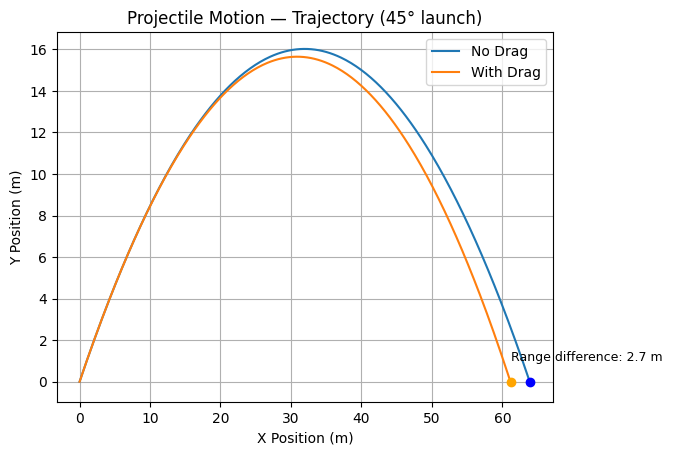

In [237]:
drag_range = A_DRAG_MATRIX[-1, 1]       # x at the last recorded step = landing point
ideal_range = A_IDEAL_MATRIX[-1, 1]
range_diff = ideal_range - drag_range   # how much farther the ideal case travels

plt.plot(A_IDEAL_MATRIX[:, 1], A_IDEAL_MATRIX[:, 2], label='No Drag')   # col 1 = x, col 2 = y
plt.plot(A_DRAG_MATRIX[:, 1], A_DRAG_MATRIX[:, 2], label='With Drag')
plt.scatter([ideal_range], [0], color='blue', zorder=5)     # mark ideal landing point
plt.scatter([drag_range], [0], color='orange', zorder=5)    # mark drag landing point
plt.annotate(f'Range difference: {range_diff:.1f} m', xy=(drag_range, 1), fontsize=9)
plt.title('Projectile Motion — Trajectory (45° launch)')
plt.xlabel('X Position (m)')
plt.ylabel('Y Position (m)')
plt.legend()
plt.grid(True)
plt.show()


### Discussion — What do you notice?

1. **Which trajectory lands farther?** By how many meters? Is that a big difference or a small one given the total range?
2. **Is the no-drag trajectory symmetric?** Does it look the same going up as coming down? Should it be, based on the physics?
3. **Is the drag trajectory symmetric?** Why or why not? Think about what drag is doing to horizontal speed during ascent vs. descent.
4. **What would happen if the ball were much lighter** (say, 0.1 kg instead of 10 kg)? Try it — change `mass` in the parameters cell and re-run.

## Part B — Range vs. Launch Angle

Part A showed one angle. But which angle gives the *maximum range*?

Instead of guessing, we simulate 89 different launch angles (1° through 89°) and record the range for each. This kind of systematic sweep is something computers are uniquely good at — it would take hours by hand, but a few seconds for Python.

### Why is 45° optimal without drag? — The Derivation

We can derive the range formula directly from the kinematic equations. The projectile lands when $y = 0$ again:

$$y(t) = v_{0y} t - \frac{1}{2} g t^2 = 0$$

Factoring out $t$:

$$t \left( v_{0y} - \frac{1}{2} g t \right) = 0$$

The non-trivial solution (ignoring $t = 0$, the launch moment) gives the **time of flight**:

$$t_{land} = \frac{2 v_{0y}}{g} = \frac{2 v_0 \sin\theta}{g}$$

Substituting into the horizontal position equation $x = v_{0x} \cdot t$, and using $v_{0x} = v_0 \cos\theta$:

$$R = v_0 \cos\theta \cdot \frac{2 v_0 \sin\theta}{g} = \frac{2 v_0^2 \sin\theta \cos\theta}{g}$$

Using the double-angle identity $2\sin\theta\cos\theta = \sin(2\theta)$:

$$\boxed{R = \frac{v_0^2 \sin(2\theta)}{g}}$$

Since $\sin(2\theta)$ is maximized when $2\theta = 90°$, the optimal launch angle is $\theta = 45°$. The math guarantees this — no simulation needed. But we'll verify it computationally below, and then see what happens when drag is added.

### With drag, the optimal angle shifts

Air resistance punishes high-angle launches more than low-angle ones. A high-angle shot stays in the air longer, giving drag more time to act. As a result, the optimal angle with drag is **less than 45°** — a flatter trajectory minimizes the time spent fighting the air.

In [238]:
B_DRAG_MATRIX = []    # will store [angle, range] for drag case
B_IDEAL_MATRIX = []   # will store [angle, range] for ideal case

alpha = 1             # start at 1° — a 0° launch goes nowhere (horizontal into the ground)

while alpha < 90:     # sweep all angles up to 89° (90° launches straight up, range = 0)

    # ── DRAG case for this angle ───────────────────────────────────────────
    x_pos, y_pos = x_0, y_0                        # reset to origin for each angle
    curr_v_x = v_0 * m.cos(m.radians(alpha))       # horizontal velocity for this angle
    curr_v_y = v_0 * m.sin(m.radians(alpha))       # vertical velocity for this angle

    while y_pos >= 0:                               # simulate until landing
        x_pos = x_pos + curr_v_x * time_step
        y_pos = y_pos + curr_v_y * time_step
        v_mag = m.sqrt(curr_v_x**2 + curr_v_y**2)  # total speed for drag term
        curr_v_x = curr_v_x + a_x * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_x * v_mag / mass * time_step)
        curr_v_y = curr_v_y + a_y * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_y * v_mag / mass * time_step)

    B_DRAG_MATRIX.append([alpha, x_pos])            # record the range for this angle

    # ── IDEAL case for this angle ──────────────────────────────────────────
    x_pos, y_pos = x_0, y_0
    curr_v_x = v_0 * m.cos(m.radians(alpha))
    curr_v_y = v_0 * m.sin(m.radians(alpha))

    while y_pos >= 0:                               # same loop, no drag
        x_pos = x_pos + curr_v_x * time_step
        y_pos = y_pos + curr_v_y * time_step
        curr_v_x = curr_v_x + a_x * time_step
        curr_v_y = curr_v_y + a_y * time_step

    B_IDEAL_MATRIX.append([alpha, x_pos])

    alpha += 1    # next angle

B_DRAG_MATRIX = np.array(B_DRAG_MATRIX)
B_IDEAL_MATRIX = np.array(B_IDEAL_MATRIX)


### Part B — Plot
Dashed vertical lines mark the optimal angle for each case. Notice how drag shifts the peak.

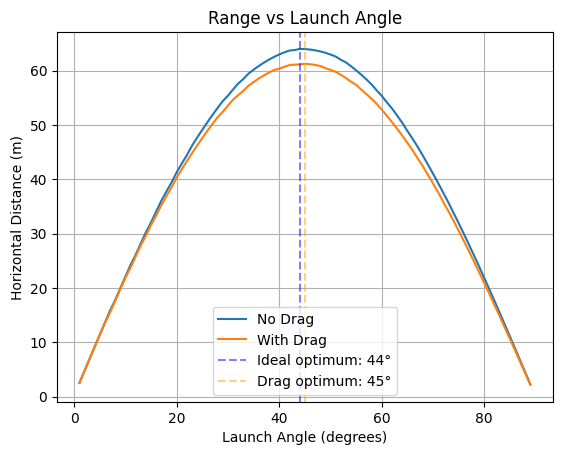

In [239]:
ideal_opt_idx = np.argmax(B_IDEAL_MATRIX[:, 1])    # find the index of the largest range (no drag)
drag_opt_idx = np.argmax(B_DRAG_MATRIX[:, 1])      # find the index of the largest range (with drag)
ideal_opt_angle = B_IDEAL_MATRIX[ideal_opt_idx, 0] # look up the angle at that index
drag_opt_angle = B_DRAG_MATRIX[drag_opt_idx, 0]    # look up the angle at that index

plt.plot(B_IDEAL_MATRIX[:, 0], B_IDEAL_MATRIX[:, 1], label='No Drag')
plt.plot(B_DRAG_MATRIX[:, 0], B_DRAG_MATRIX[:, 1], label='With Drag')

# dashed vertical lines highlight where the peak range occurs for each case
plt.axvline(x=ideal_opt_angle, color='blue', linestyle='--', alpha=0.5, label=f'Ideal optimum: {ideal_opt_angle:.0f}°')
plt.axvline(x=drag_opt_angle, color='orange', linestyle='--', alpha=0.5, label=f'Drag optimum: {drag_opt_angle:.0f}°')

plt.title('Range vs Launch Angle')
plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Horizontal Distance (m)')
plt.legend()
plt.grid(True)
plt.show()


### Discussion — What do you notice?

1. **What angle gives the maximum range with drag?** Is it above or below 45°? Does this match the prediction from the intro?
2. **Look at the two curves near 80°–89°.** Why do both drop so sharply at very high angles?
3. **Why does drag affect high-angle shots more than low-angle shots?** Think about how long each trajectory spends in the air.
4. **Try decreasing `mass` to 0.5 kg** and re-running. How does the optimal drag angle change? What does this tell you about the relationship between mass and air resistance effects?

## Part C — Trajectory Family: Multiple Launch Angles

Parts A and B showed one angle at a time, or just the final range. Now let's overlay the full trajectories for **every 10°** from 10° to 80° — both with and without drag — so we can see the entire family of curves at once.

This kind of plot is a classic physics visualization: you can immediately see how angle affects both the height and the range of the trajectory, and how drag compresses each curve.

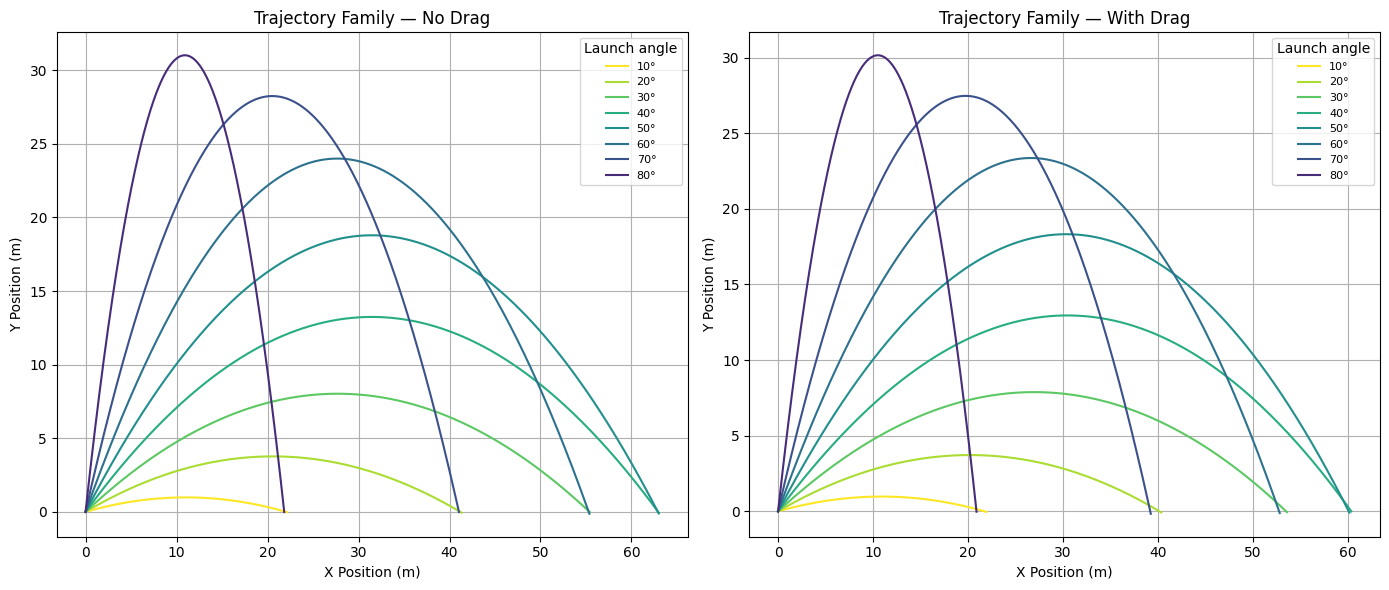

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # two side-by-side subplots
angles_to_plot = range(10, 81, 10)               # 10°, 20°, 30°, ..., 80°
colors = plt.cm.viridis_r([i / 8 for i in range(len(list(angles_to_plot)))])  # color gradient

for idx, angle in enumerate(angles_to_plot):

    # ── IDEAL trajectory for this angle ────────────────────────────────────
    traj_x, traj_y = [x_0], [y_0]              # start at origin
    curr_v_x = v_0 * m.cos(m.radians(angle))   # initial velocity components
    curr_v_y = v_0 * m.sin(m.radians(angle))
    x_pos, y_pos = x_0, y_0

    while y_pos >= 0:                           # simulate until landing
        x_pos = x_pos + curr_v_x * time_step
        y_pos = y_pos + curr_v_y * time_step
        curr_v_x = curr_v_x + a_x * time_step
        curr_v_y = curr_v_y + a_y * time_step
        traj_x.append(x_pos)
        traj_y.append(y_pos)

    axes[0].plot(traj_x, traj_y, color=colors[idx], label=f'{angle}°')  # plot on left subplot

    # ── DRAG trajectory for this angle ─────────────────────────────────────
    traj_x, traj_y = [x_0], [y_0]
    curr_v_x = v_0 * m.cos(m.radians(angle))
    curr_v_y = v_0 * m.sin(m.radians(angle))
    x_pos, y_pos = x_0, y_0

    while y_pos >= 0:
        x_pos = x_pos + curr_v_x * time_step
        y_pos = y_pos + curr_v_y * time_step
        v_mag = m.sqrt(curr_v_x**2 + curr_v_y**2)   # total speed for drag
        curr_v_x = curr_v_x + a_x * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_x * v_mag / mass * time_step)
        curr_v_y = curr_v_y + a_y * time_step - (0.5 * C_d * rho_air * CS_Area * curr_v_y * v_mag / mass * time_step)
        traj_x.append(x_pos)
        traj_y.append(y_pos)

    axes[1].plot(traj_x, traj_y, color=colors[idx], label=f'{angle}°')  # plot on right subplot

# format left subplot (no drag)
axes[0].set_title('Trajectory Family — No Drag')
axes[0].set_xlabel('X Position (m)')
axes[0].set_ylabel('Y Position (m)')
axes[0].legend(title='Launch angle', fontsize=8)
axes[0].grid(True)

# format right subplot (with drag)
axes[1].set_title('Trajectory Family — With Drag')
axes[1].set_xlabel('X Position (m)')
axes[1].set_ylabel('Y Position (m)')
axes[1].legend(title='Launch angle', fontsize=8)
axes[1].grid(True)

plt.tight_layout()   # prevent subplot labels from overlapping
plt.show()


### Discussion — What do you notice?

1. **Compare the two plots side by side.** Which angles are most affected by drag? Low angles, high angles, or both equally?
2. **Look at the 80° trajectory** in both plots. With drag, it lands noticeably shorter. Why does a nearly-vertical shot lose so much range to drag?
3. **Look at the 10° trajectory.** Is it affected much by drag? Why might low-angle shots be less sensitive to air resistance?
4. **Which angle gives the tallest trajectory?** Is it the same as the one that gives the longest range? Why are these different?

## Summary

### Key physics takeaways
- Without air resistance, projectile motion follows a perfect parabola and range is maximized at **45°**
- Air drag opposes motion in the direction of travel — it slows both horizontal and vertical velocity
- Drag makes trajectories **asymmetric**: slower ascent, faster descent relative to the no-drag case
- With drag, the optimal launch angle shifts **below 45°** — a flatter trajectory minimizes time in the air and reduces the total energy lost to drag
- Heavier objects are less affected by drag relative to their inertia (same force, more mass = less deceleration)

### Key computational takeaways
- Some physics problems can't be solved with algebra — we need **numerical methods**
- The **Euler method** breaks time into tiny steps and updates position and velocity incrementally
- Smaller time steps give more accurate results, but take more computation
- Computers let us sweep through thousands of scenarios (89 angles × 2 cases) in seconds

---

## Extension questions

These are good starting points for a homework problem or short project:

1. **Wind:** What would happen if there were a constant headwind (horizontal force opposing motion)? How would you modify the code to include it? Would the optimal angle go up or down?
2. **Elevation:** What if the projectile is launched from a cliff 50 meters above the landing zone? How does the optimal angle change?
3. **Variable air density:** Air gets thinner at higher altitudes. How would you model a drag force that decreases as the projectile climbs? Would this make drag matter more or less for high-angle launches?
4. **Different objects:** Look up the drag coefficient and size of a golf ball, a baseball, and a badminton shuttlecock. Simulate all three at the same launch speed. Which is affected most by drag? Does the result surprise you?